# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,QueryUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,SensorReadingUTC_SecondsFromPrior,Historical
0,1762640824,1763245420,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.779999,<NA>,True
1,1762641724,1763245420,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,50.439999,<NA>,True
2,1762642624,1763245420,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.740002,<NA>,True
3,1762643524,1763245420,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.310001,<NA>,True
4,1762644424,1763245420,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.590000,<NA>,True


In [2]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,SensorReadingUTC,QueryUTC,Historical,SensorReadingF,SensorReadingRh
0,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1762640824,1763245420,True,70.592003,49.779999
1,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1762641724,1763245420,True,70.484001,50.439999
2,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1762642624,1763245420,True,70.375999,49.740002
3,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1762643524,1763245420,True,70.501999,49.310001
4,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1762644424,1763245420,True,70.447998,49.590000


In [3]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensors.parquet') LIMIT 5").df()

,Source,SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection,DeviceName,SensorReadingUTC,QueryUTC,Historical
0,LI-COR,licor:10740550-10740550-2,ICSC__010C149________RH,RH,licor:10740550,RH,FLOATER,Unknown,FLOATER,None,ICSC__010C149_______,1763245636,1763245636,False
1,LI-COR,licor:10740550-10740550-1,ICSC__010C149________Temperature,Temperature,licor:10740550,Temperature,FLOATER,Unknown,FLOATER,None,ICSC__010C149_______,1763245636,1763245636,False
2,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1763033607,1763245418,True
3,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1763048007,1763245418,True
4,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1762722807,1763245418,True


In [4]:
duckdb.sql("SELECT * FROM read_parquet('../data/devices.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,LI-COR,licor:10740550,ICSC__010C149_______,"licor:10740550-10740550-2, licor:10740550-1074...","ICSC__010C149________RH, ICSC__010C149________...","RH, Temperature",RH,FLOATER,Unknown,FLOATER,None
1,Coris,coris:12167,Peabody TH-L Upper Great Hall D0B2,"coris:21378, coris:21378, coris:21378, coris:2...","RH KGL 21_D0B2, RH KGL 21_D0B2, RH KGL 21_D0B2...","Humidity, Humidity, Humidity, Humidity, Humidi...",D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
2,Conserv,conserv:333:c009072,BBARCH0100001_______,"conserv:333:c009072:RH, conserv:333:c009072:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None
3,Conserv,conserv:333:c009073,BBARCHB100116_______,"conserv:333:c009073:RH, conserv:333:c009073:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None
4,Conserv,conserv:333:c009081,BCSC__01H103________,"conserv:333:c009081:RH, conserv:333:c009081:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None


In [5]:
duckdb.sql("SELECT * FROM read_parquet('../data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1762918403,2025-11-11 20:33:23,2025-11-11 13:33:23-07:00,2025-11-11,15:33:23,2025,11,Tuesday,2,15,3,PM
1,1762787332,2025-11-10 08:08:52,2025-11-10 01:08:52-07:00,2025-11-10,03:08:52,2025,11,Monday,1,3,3,AM
2,1762918407,2025-11-11 20:33:27,2025-11-11 13:33:27-07:00,2025-11-11,15:33:27,2025,11,Tuesday,2,15,3,PM
3,1763180558,2025-11-14 21:22:38,2025-11-14 14:22:38-07:00,2025-11-14,16:22:38,2025,11,Friday,5,16,4,PM
4,1762787350,2025-11-10 08:09:10,2025-11-10 01:09:10-07:00,2025-11-10,03:09:10,2025,11,Monday,1,3,3,AM


In [6]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings_daily.parquet') LIMIT 5").df()

,Source,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-11-15,conserv:333:c008733:RH,1,0.000000,44.770000,NaN,44.770000,NaN,44.770000
1,Conserv,2025-11-15,conserv:333:c008733:Temperature,1,72.248001,0.000000,72.248001,NaN,72.248001,NaN
2,Conserv,2025-11-15,conserv:333:c008781:RH,1,0.000000,47.709999,NaN,47.709999,NaN,47.709999
3,Conserv,2025-11-15,conserv:333:c008781:Temperature,1,71.690002,0.000000,71.690002,NaN,71.690002,NaN
4,Conserv,2025-11-15,conserv:333:c008784:RH,1,0.000000,45.080002,NaN,45.080002,NaN,45.080002


In [7]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings_daily.parquet') LIMIT 5").df()

,Source,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-11-15,conserv:333:c008733,1,72.248001,44.770000,72.248001,44.770000,72.248001,44.770000
1,Conserv,2025-11-15,conserv:333:c008781,1,71.690002,47.709999,71.690002,47.709999,71.690002,47.709999
2,Conserv,2025-11-15,conserv:333:c008784,1,71.959999,45.080002,71.959999,45.080002,71.959999,45.080002
3,Conserv,2025-11-15,conserv:333:c008924,1,71.816002,45.310001,71.816002,45.310001,71.816002,45.310001
4,Conserv,2025-11-15,conserv:333:c008949,1,71.545998,44.669998,71.545998,44.669998,71.545998,44.669998


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

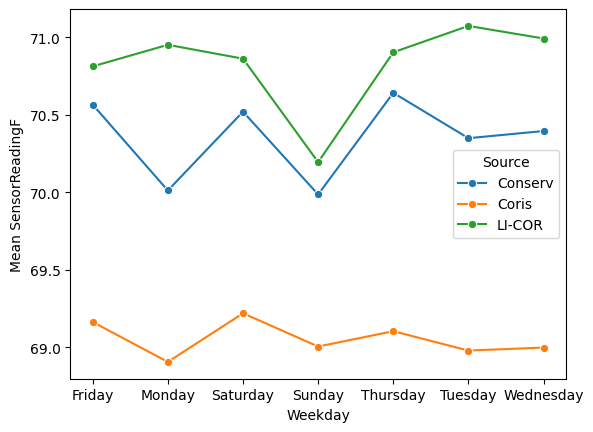

In [8]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u ON 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

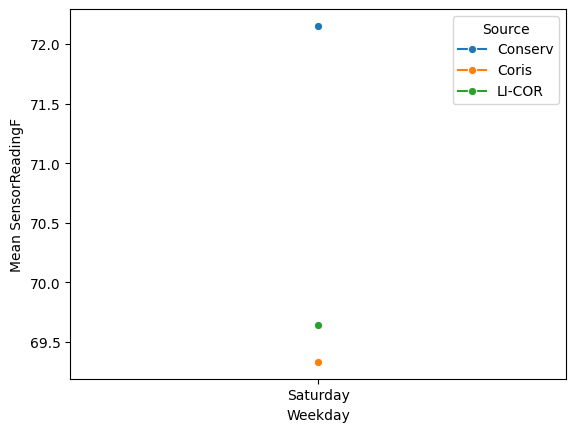

In [9]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('../data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

# need DISTINCT on utcs to prevent duplication!

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

In [10]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT dr.Source, Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID) as 'Count of Devices'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('../data/devices.parquet') AS d
        ON d.DeviceID = dr.DeviceID
    GROUP BY dr.Source, Building
    ORDER BY min(date)
""").df()

,Source,Building,First Reading,Count of Devices
0,LI-COR,Unknown,2025-11-08,3
1,Conserv,Unknown,2025-11-08,30
2,Coris,Yale Peabody Museum,2025-11-08,2
3,Coris,Kline Geology Laboratory,2025-11-08,1


In [11]:
# Readings that differ from the Query UTC. These could be data errors if the difference is large.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1763245418,1762640607,-10080.183333
1,1763245416,1762640607,-10080.150000
2,1763245414,1762640607,-10080.116667
3,1763245413,1762640607,-10080.100000
4,1763245411,1762640607,-10080.066667
...,...,...,...
47461,1763245536,1763245448,-1.466667
47462,1763245536,1763245472,-1.066667
47463,1763245536,1763245472,-1.066667
47464,1763245420,1763245357,-1.050000
